# Lab Day 1 — Mạng nơ-ron và thí nghiệm huấn luyện (Forest CoverType)

**Sinh viên:** 523H0148 · **Repo:** `K4-Track4-Day1-Neuralnetwork` (nộp bằng `git push`, không nén zip) · **GPU:** Colab T4

Notebook chạy từ đầu đến cuối bằng *Restart & Run All* (≈ 35–45 phút trên T4), seed cố định, output được giữ lại.
Nếu `../results/<exp_id>.json` đã có đúng cấu hình đó (ví dụ sau khi Colab ngắt kết nối giữa chừng) thì `run_and_log` đọc lại thay vì huấn luyện lại; trên runtime mới (thư mục `results/` trống) mọi thí nghiệm được chạy lại từ đầu.
Cấu trúc repo = cấu trúc nộp bài: code ở `code/` (thư mục chạy notebook), kết quả ghi vào `../results/`, `../figures/`,
`../experiments.xlsx`, `../predictions_eval.csv`, `../eval_result.json`; dữ liệu ở `../data`.

**Quy ước của notebook**
- Mỗi thí nghiệm: ô markdown **Dự đoán trước** → ô code (chạy) → ô markdown **Đối chiếu**. Dự đoán được viết dựa trên cơ chế (slide Chương 3–5).
  *Minh bạch:* trước lần chạy cuối này tôi đã chạy một vòng thăm dò nhanh **chỉ trên val** để biết lưới lr nên trải đến đâu
  (lr tốt nhất của SGD+momentum và Adam nằm ở mép lưới ban đầu nên lưới được mở rộng). Các dự đoán dưới đây vẫn là kỳ vọng theo cơ chế; chỗ nào kết quả không như dự đoán được nêu ở ô Đối chiếu.
- Chọn lr / cấu hình **chỉ bằng val**. Tập `eval` chỉ được đọc ở Part 4, sau khi cấu hình cuối cùng đã chốt.
- Độ nhiễu seed: 3 seed baseline (Part 2) → ngưỡng 2σ dùng để kết luận "A tốt hơn B" ở mọi nhóm thí nghiệm.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess, math, tempfile
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display

# Chạy từ thư mục code/ của repo. (Colab: !git clone https://github.com/KhanhNamYeh/K4-Track4-Day1-Neuralnetwork.git
#  rồi %cd K4-Track4-Day1-Neuralnetwork/code)
REPO_ROOT = ".."     # thư mục gốc repo (chứa data/, scripts/, templates/)
OUT_DIR   = ".."     # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv, eval_result.json
sys.path.insert(0, os.getcwd())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval, compute_loss
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.14.0+cu126 | device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


## Part 0 — Dữ liệu
Chia sẵn bằng metadata (`scripts/split_data.py`) → tách validation 20% từ train (phân tầng, seed 42) → chuẩn hoá 10 cột số bằng
thống kê của phần train còn lại → đưa lên GPU một lần (không dùng `DataLoader`).

In [2]:
r = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, capture_output=True, text=True)
print(r.stdout[-700:]); assert r.returncode == 0, r.stderr

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
X_tr, y_tr, X_val, y_val = data["X_tr"], data["y_tr"], data["X_val"], data["y_val"]
assert (len(X_tr), len(X_val), len(data["X_eval"])) == (371_847, 92_962, 116_203)

# tỉ lệ lớp ở 3 tập
ratio = lambda y: torch.bincount(y, minlength=7).float().div(len(y)).cpu().numpy().round(4)
print(pd.DataFrame({"train": ratio(y_tr), "val": ratio(y_val), "eval": ratio(data["y_eval"])}).T.to_string())
# 10 cột số của X_tr phải có mean≈0, std≈1 (thống kê tính CHỈ trên train)
print("mean 10 cột số (train):", X_tr[:, :10].mean(0).cpu().numpy().round(4))
print("std  10 cột số (train):", X_tr[:, :10].std(0).cpu().numpy().round(4))
print("mean 10 cột số (val)  :", X_val[:, :10].mean(0).cpu().numpy().round(3), "(≈ 0 nhưng không chính xác 0: đúng vì dùng thống kê của train)")
pm = data["majority_acc_val"]; print("macro-F1 của 'luôn đoán lớp đa số' trên val ≈", round((2 * pm / (1 + pm)) / 7, 4), "(chỉ lớp 1 có F1 > 0)")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data\processed\train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data\processed\eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876



train 371,847 | val 92,962 | eval 116,203
'luôn đoán lớp đa số' (lớp 1) trên val: acc = 0.4876
            0       1       2       3       4       5       6
train  0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353
val    0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353
eval   0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353
mean 10 cột số (train): [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  10 cột số (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
mean 10 cột số (val)  : [ 0.002  0.002 -0.002  0.    -0.     0.006 -0.004  0.002  0.005  0.004] (≈ 0 nhưng không chính xác 0: đúng vì dùng thống kê của train)
macro-F1 của 'luôn đoán lớp đa số' trên val ≈ 0.0936 (chỉ lớp 1 có F1 > 0)


**Vì sao thống kê chuẩn hoá chỉ lấy từ train?** Nếu mean/std tính cả val/eval thì thông tin của các mẫu "chưa từng thấy" đã lọt vào bước tiền xử lý (rò rỉ),
làm điểm val/eval lạc quan hơn thực tế; ngoài ra khi triển khai ta chỉ có thống kê của dữ liệu đã huấn luyện. `X_eval` không xuất hiện trong bất kỳ bước chọn cấu hình nào trước Part 4.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
`M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model, dropout (nếu có) chỉ sau ReLU lớp ẩn.

In [3]:
set_seed(0)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
print("số tham số:", n_params, "| kiến trúc:", [type(l).__name__ for l in model.net])

# (b) shape sau từng lớp với một lô (8, 54)
h = torch.randn(8, 54, device=device)
for layer in model.net:
    h = layer(h); print(f"{type(layer).__name__:<8} -> {tuple(h.shape)}")
assert h.shape == (8, 7)

# (c1) loss bước 0 trên val (eval mode): kỳ vọng ≈ ln 7 = 1.946
print(f"\nln 7 = {math.log(7):.4f}")
for seed in range(5):
    set_seed(seed); m = MLP(init="he").to(device)
    print(f"  seed {seed}: loss bước 0 (He) = {evaluate(m, X_val, y_val)['loss']:.4f}")

số tham số: 47879 | kiến trúc: ['Linear', 'ReLU', 'Linear', 'ReLU', 'Linear']


Linear   -> (8, 256)
ReLU     -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Linear   -> (8, 7)

ln 7 = 1.9459
  seed 0: loss bước 0 (He) = 2.2073


  seed 1: loss bước 0 (He) = 2.2691
  seed 2: loss bước 0 (He) = 1.9782
  seed 3: loss bước 0 (He) = 1.9005
  seed 4: loss bước 0 (He) = 2.3106


**Nhận xét loss bước 0:** với He init (phương sai `2/n_in` giữ độ lớn kích hoạt, *kể cả ở lớp logit*), logit ban đầu có độ lệch chuẩn ~1 nên
CE ≈ ln 7 + σ²/2 > ln 7 (cross-entropy lồi theo logit: logit lệch khỏi 0 chỉ làm tăng kỳ vọng loss). Do đó loss bước 0 nằm ở ~2.0–2.4 chứ không đúng 1.946 —
vẫn cùng bậc ln 7 (không có lỗi nhãn / softmax hai lần / thiếu chuẩn hoá, những lỗi sẽ cho loss ≫ ln 7 hoặc ≪ ln 7). Giá trị đúng 1.946 chỉ xuất hiện khi logit = 0 (xem `init=zeros` ở Part 3).

loss bước 0 = 1.9668 -> loss bước 300 = 7.38e-04; accuracy trên 20 mẫu = 1.00


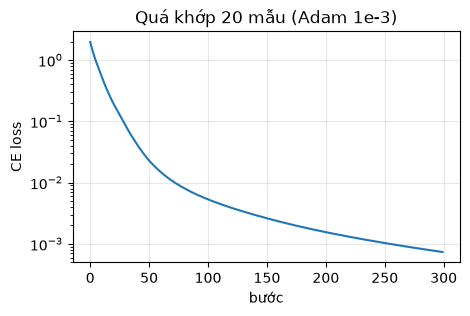

W1 (net.0.weight): |grad| = 0.4543
b1 (net.0.bias): |grad| = 0.2684
W2 (net.2.weight): |grad| = 1.7565
b2 (net.2.bias): |grad| = 0.3824
W3 (net.4.weight): |grad| = 1.9387
b3 (net.4.bias): |grad| = 0.5498
OK: mọi tham số có gradient khác None và khác 0


In [4]:
# (c2) quá khớp 20 mẫu: tắt dropout, vài trăm bước, Adam lr 1e-3
set_seed(0)
m = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
opt = torch.optim.Adam(m.parameters(), lr=1e-3)
xs, ys = X_tr[:20], y_tr[:20]
curve = []
for step in range(300):
    loss = compute_loss(m(xs), ys, "ce")
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    curve.append(loss.item())
acc20 = (m(xs).argmax(1) == ys).float().mean().item()
print(f"loss bước 0 = {curve[0]:.4f} -> loss bước 300 = {curve[-1]:.2e}; accuracy trên 20 mẫu = {acc20:.2f}")
assert curve[-1] < 1e-2 and acc20 == 1.0
plt.figure(figsize=(5, 3)); plt.semilogy(curve); plt.xlabel("bước"); plt.ylabel("CE loss"); plt.title("Quá khớp 20 mẫu (Adam 1e-3)"); plt.grid(alpha=.3); plt.show()

# (d) gradient chảy tới mọi tham số?
set_seed(0)
m = MLP(init="he").to(device)
loss = compute_loss(m(X_tr[:512]), y_tr[:512], "ce"); loss.backward()
for (n, p), name in zip(m.named_parameters(), ["W1", "b1", "W2", "b2", "W3", "b3"]):
    assert p.grad is not None and p.grad.norm() > 0
    print(f"{name} ({n}): |grad| = {p.grad.norm().item():.4f}")
print("OK: mọi tham số có gradient khác None và khác 0")

**Nhận xét Part 1:** (i) `assert` 47 879 tham số và logits `(8, 7)` đều đúng; (ii) loss bước 0 ở mức 2.0–2.4 (giải thích ở trên), cùng bậc ln 7; (iii) 20 mẫu bị học thuộc hoàn toàn
(loss → ~0, accuracy 100%) nên vòng lặp huấn luyện, nhãn và optimizer không có lỗi cơ bản; (iv) gradient của cả 6 tham số khác None và khác 0 — gradient chảy đủ.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt (train loss đo ở `eval()` trên 50 000 mẫu train cố định; val loss/acc/macro-F1;
`grad_norm` đo **trước clip**; loss bước 0; thời gian/epoch; bộ nhớ GPU; cờ `diverged`; epoch có val loss thấp nhất = "best epoch").
Baseline: `M-base`, He init, CE, **SGD+momentum 0.9**, batch 512, 20 epoch, dropout 0, không clip, FP32.

**Tìm lr cho baseline bằng val.** Dự đoán: lưới `{0.01, 0.03, 0.1, 0.3, 1.0}`; lr quá nhỏ ⇒ chưa hội tụ trong 20 epoch (val macro-F1 thấp, best epoch = cuối);
lr quá lớn (1.0 với momentum 0.9, bước hiệu dụng ~10×) ⇒ dao động. Điểm tốt nhất ở khoảng giữa.

In [5]:
RESULTS = {}      # exp_id -> kết quả (giữ trong RAM; JSON/ảnh đã ghi ra đĩa)
EXP_ORDER = []    # thứ tự chạy -> thứ tự dòng trong experiments.xlsx
lrtag = lambda lr: (f"{lr:.0e}".replace("e-0", "e-") if lr < 0.01 else f"{lr:g}")

def run_and_log(cfg, force=False):
    # chạy, hoặc đọc lại từ results/<exp_id>.json nếu cấu hình y hệt (cho phép chạy tiếp khi Colab ngắt kết nối)
    path = f"{OUT_DIR}/results/{cfg['exp_id']}.json"
    want = json.loads(json.dumps({**DEFAULT_CFG, **cfg}))
    tag = ""
    saved = None
    if not force and os.path.exists(path):
        try:
            saved = json.load(open(path, encoding="utf-8"))
            if saved["cfg"] != want: saved = None
        except (json.JSONDecodeError, KeyError):
            saved = None   # file ghi dở khi Colab ngắt kết nối -> chạy lại
    if saved is not None:
        r = dict(cfg=saved["cfg"], history=saved["history"], summary=saved["summary"], best_state=None); tag = " [đọc lại từ results/]"
    else:
        r = run_experiment(cfg, data, verbose=False)
        save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{cfg['exp_id']}.png")
    RESULTS[cfg["exp_id"]] = r; EXP_ORDER.append(cfg["exp_id"])
    s = r["summary"]
    print(f"{cfg['exp_id']:<26} lr={cfg['lr']:<7g} step0={s['step0_loss']:.3f} best_ep={s['best_epoch']!s:>4} "
          f"val_loss={s['best_val_loss']:.4f} acc={s['val_acc']:.4f} macroF1={s['val_macro_f1']:.4f} "
          f"t/ep={s['time_per_epoch_s']:.2f}s diverged={s['diverged']}{tag}")
    return r

def ensure_state(exp_id):
    # final_eval cần trọng số best epoch (không lưu ra đĩa): nếu kết quả được đọc lại từ JSON thì chạy lại đúng cấu hình đó
    if RESULTS[exp_id]["best_state"] is None:
        r = run_experiment(RESULTS[exp_id]["cfg"], data, verbose=False)
        d = abs(r["summary"]["val_macro_f1"] - RESULTS[exp_id]["summary"]["val_macro_f1"])
        print(f"{exp_id}: chạy lại để lấy trọng số; chênh lệch val macro-F1 so với lần trước = {d:.2e}")
        RESULTS[exp_id]["best_state"] = r["best_state"]
    return RESULTS[exp_id]

# khởi động GPU (không lưu) để thời gian/epoch của thí nghiệm đầu tiên không bị nhiễu bởi khởi tạo CUDA
_ = run_experiment({**DEFAULT_CFG, "lr": 0.1, "epochs": 2, "exp_id": "warmup"}, data, verbose=False)

SGDM_LRS = [0.01, 0.03, 0.1, 0.3, 1.0]
for lr in SGDM_LRS:
    run_and_log({**DEFAULT_CFG, "exp_id": f"opt-sgdm-lr{lrtag(lr)}", "group": "optimizer", "lr": lr,
                 "description": f"SGD+momentum 0.9, lr={lr:g} (quét lr cho baseline)"})
best_lr = max(SGDM_LRS, key=lambda lr: RESULTS[f"opt-sgdm-lr{lrtag(lr)}"]["summary"]["val_macro_f1"])
print("\nlr baseline chọn theo val macro-F1:", best_lr)
plot_compare([RESULTS[f"opt-sgdm-lr{lrtag(lr)}"] for lr in SGDM_LRS], ["val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_baseline_lr.png", "Quét lr cho baseline SGD+momentum (val)")

opt-sgdm-lr0.01            lr=0.01    step0=2.269 best_ep=  20 val_loss=0.3110 acc=0.8747 macroF1=0.7613 t/ep=2.14s diverged=N [đọc lại từ results/]


opt-sgdm-lr0.03            lr=0.03    step0=2.269 best_ep=  20 val_loss=0.2660 acc=0.8921 macroF1=0.8170 t/ep=2.19s diverged=N [đọc lại từ results/]


opt-sgdm-lr0.1             lr=0.1     step0=2.269 best_ep=  18 val_loss=0.2379 acc=0.9054 macroF1=0.8390 t/ep=2.16s diverged=N [đọc lại từ results/]


opt-sgdm-lr0.3             lr=0.3     step0=2.269 best_ep=  19 val_loss=0.2318 acc=0.9090 macroF1=0.8573 t/ep=2.14s diverged=N [đọc lại từ results/]


opt-sgdm-lr1               lr=1       step0=2.269 best_ep=  19 val_loss=0.3335 acc=0.8662 macroF1=0.7732 t/ep=2.14s diverged=N [đọc lại từ results/]

lr baseline chọn theo val macro-F1: 0.3


**Đối chiếu (quét lr):** val macro-F1 tăng đều từ lr 0.01 (0.761) → 0.03 (0.817) → 0.1 (0.839) → **0.3 (0.857)** rồi tụt ở lr 1.0 (0.773, grad_norm max 9.7). Đúng dạng chữ U dự đoán: lr nhỏ chưa hội tụ sau 20 epoch (best epoch = 20), lr 1.0 với momentum 0.9 dao động. Baseline dùng lr = 0.3.

In [6]:
BASE = {**DEFAULT_CFG, "lr": best_lr}
for s in (1, 2, 3):
    run_and_log({**BASE, "exp_id": f"base-s{s}", "group": "baseline", "seed": s,
                 "description": f"Baseline M-base, lr={best_lr:g}, seed {s}"})
ids = [f"base-s{s}" for s in (1, 2, 3)]
f1 = np.array([RESULTS[i]["summary"]["val_macro_f1"] for i in ids])
acc = np.array([RESULTS[i]["summary"]["val_acc"] for i in ids])
vl = np.array([RESULTS[i]["summary"]["best_val_loss"] for i in ids])
F1_MEAN, F1_STD = f1.mean(), f1.std(ddof=1)
NOISE2 = 2 * F1_STD
print(f"\nval macro-F1 = {F1_MEAN:.4f} ± {F1_STD:.4f} | val acc = {acc.mean():.4f} ± {acc.std(ddof=1):.4f} | val loss = {vl.mean():.4f} ± {vl.std(ddof=1):.4f}")
print(f"NGƯỠNG NHIỄU 2σ (val macro-F1) = {NOISE2:.4f}   (3 seed; σ chỉ là ước lượng thô)")
print(f"mốc 'đoán đa số': acc = {data['majority_acc_val']:.4f}; baseline vượt mốc: {acc.min() > data['majority_acc_val']}")
plot_compare([RESULTS[i] for i in ids], ["val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_baseline_seeds.png", "Baseline với 3 seed (đo độ nhiễu)")

def table(ids, ref_ids=None):
    rows = []
    for i in ids:
        s, c = RESULTS[i]["summary"], RESULTS[i]["cfg"]
        d = s["val_macro_f1"] - F1_MEAN
        rows.append(dict(exp_id=i, lr=c["lr"], best_ep=s["best_epoch"], val_loss=s["best_val_loss"], val_acc=s["val_acc"],
                         val_f1=s["val_macro_f1"], d_f1_vs_base=d, beyond_2sigma="Có" if abs(d) > NOISE2 else "Không",
                         gap_val_train=s["final_val_loss"] - s["final_train_loss"], s_per_ep=s["time_per_epoch_s"],
                         mem_MB=s["peak_mem_MB"], diverged=s["diverged"]))
    return pd.DataFrame(rows).set_index("exp_id").round(4)
display(table(EXP_ORDER[:5] + ids))

base-s1                    lr=0.3     step0=2.269 best_ep=  19 val_loss=0.2318 acc=0.9090 macroF1=0.8573 t/ep=2.12s diverged=N [đọc lại từ results/]


base-s2                    lr=0.3     step0=1.978 best_ep=  16 val_loss=0.2145 acc=0.9144 macroF1=0.8618 t/ep=1.76s diverged=N [đọc lại từ results/]


base-s3                    lr=0.3     step0=1.901 best_ep=  18 val_loss=0.2208 acc=0.9121 macroF1=0.8630 t/ep=2.10s diverged=N [đọc lại từ results/]

val macro-F1 = 0.8607 ± 0.0030 | val acc = 0.9118 ± 0.0027 | val loss = 0.2224 ± 0.0088
NGƯỠNG NHIỄU 2σ (val macro-F1) = 0.0060   (3 seed; σ chỉ là ước lượng thô)
mốc 'đoán đa số': acc = 0.4876; baseline vượt mốc: True


,lr,best_ep,val_loss,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,gap_val_train,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,
opt-sgdm-lr0.01,0.01,20,0.3110,0.8747,0.7613,-0.0995,Có,0.0115,2.1434,173.2891,N
opt-sgdm-lr0.03,0.03,20,0.2660,0.8921,0.8170,-0.0438,Có,0.0187,2.1872,173.4722,N
opt-sgdm-lr0.1,0.10,18,0.2379,0.9054,0.8390,-0.0217,Có,0.0207,2.1604,173.6553,N
opt-sgdm-lr0.3,0.30,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,2.1367,173.8384,N
opt-sgdm-lr1,1.00,19,0.3335,0.8662,0.7732,-0.0875,Có,0.0186,2.1411,174.0215,N
base-s1,0.30,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,2.1210,174.2046,N
base-s2,0.30,16,0.2145,0.9144,0.8618,0.0011,Không,0.0288,1.7606,174.3877,N
base-s3,0.30,18,0.2208,0.9121,0.8630,0.0023,Không,0.0250,2.0975,174.5708,N


**Nhận xét baseline:** train/val loss giảm đều tới cuối (best epoch 16–19), khoảng cách val−train nhỏ (≈ 0.03) và val còn đi xuống ⇒ chưa quá khớp, chưa hội tụ hẳn. Val acc ≈ 0.91 ≫ mốc 0.4876. Độ nhiễu giữa 3 seed: val macro-F1 0.8607 ± 0.0030 ⇒ **ngưỡng 2σ = 0.0060** dùng cho mọi so sánh bên dưới (σ từ 3 seed chỉ là ước lượng thô). grad_norm TB ≈ 0.34–0.38 với một gai ≈ 2.8 ở epoch đầu.

## Part 3 — Thí nghiệm (phủ cả 7 chủ đề)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố so với baseline (`BASE`, seed 1) → chạy → **đối chiếu** với dự đoán và với ngưỡng nhiễu 2σ.
Cột `d_f1_vs_base` = val macro-F1 − trung bình 3 seed baseline; `beyond_2sigma` = |d| > 2σ.

In [7]:
def mk(exp_id, group, description, notes="", **over):
    return {**BASE, "exp_id": exp_id, "group": group, "description": description, "notes": notes, **over}
B1 = RESULTS["base-s1"]

### Chủ đề 2 — Bộ tối ưu hoá (`optimizer`)
**Dự đoán trước:** (1) SGD thuần cần lr lớn hơn SGD+momentum khoảng 10 lần (momentum 0.9 làm bước hiệu dụng ≈ lr/(1−0.9)); (2) Adam/AdamW ít nhạy với lr hơn
(chuẩn hoá bước theo độ lớn gradient từng tham số) và ở lr ~1e-3–1e-2 sẽ nhanh hơn SGD+momentum trong 20 epoch; (3) khi mỗi bộ được chỉnh lr công bằng, khoảng cách thu hẹp lại;
(4) với `weight_decay=0`, AdamW ≡ Adam (kiểm chứng bằng một lần chạy); với wd=0.01 chênh lệch nhỏ vì mạng chưa quá khớp.
Lưới lr: SGD {0.3, 1, 3}; Adam và AdamW {3e-4, 1e-3, 3e-3, 1e-2} (AdamW `weight_decay=0.01`); SGD+momentum dùng lại 5 lần quét ở Part 2.

opt-sgd-lr0.3              lr=0.3     step0=2.269 best_ep=  18 val_loss=0.2803 acc=0.8871 macroF1=0.8163 t/ep=2.13s diverged=N [đọc lại từ results/]


opt-sgd-lr1                lr=1       step0=2.269 best_ep=  18 val_loss=0.2522 acc=0.9000 macroF1=0.8344 t/ep=2.11s diverged=N [đọc lại từ results/]


opt-sgd-lr3                lr=3       step0=2.269 best_ep=  18 val_loss=0.3698 acc=0.8511 macroF1=0.6155 t/ep=2.09s diverged=N [đọc lại từ results/]


opt-adam-lr3e-4            lr=0.0003  step0=2.269 best_ep=  20 val_loss=0.3135 acc=0.8727 macroF1=0.7877 t/ep=2.40s diverged=N [đọc lại từ results/]


opt-adam-lr1e-3            lr=0.001   step0=2.269 best_ep=  19 val_loss=0.2494 acc=0.8993 macroF1=0.8456 t/ep=2.33s diverged=N [đọc lại từ results/]


...

opt-adamw-lr3e-3           lr=0.003   step0=2.269 best_ep=  18 val_loss=0.2161 acc=0.9130 macroF1=0.8646 t/ep=2.33s diverged=N [đọc lại từ results/]


opt-adamw-lr0.01           lr=0.01    step0=2.269 best_ep=  15 val_loss=0.2360 acc=0.9043 macroF1=0.8492 t/ep=2.37s diverged=N [đọc lại từ results/]


opt-adamw-wd0-lr3e-3       lr=0.003   step0=2.269 best_ep=  19 val_loss=0.2145 acc=0.9153 macroF1=0.8677 t/ep=2.37s diverged=N [đọc lại từ results/]

Adam(3e-3) vs AdamW(wd=0, 3e-3): val_loss 0.21449648476578467 0.21449648476578467 | macro-F1 0.8677466182111557 0.8677466182111557


,lr,best_ep,val_loss,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,gap_val_train,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,
opt-sgd-lr0.3,0.3000,18,0.2803,0.8871,0.8163,-0.0444,Có,0.0131,2.1301,174.5708,N
opt-sgd-lr1,1.0000,18,0.2522,0.9000,0.8344,-0.0263,Có,0.0246,2.1072,174.7539,N
opt-sgd-lr3,3.0000,18,0.3698,0.8511,0.6155,-0.2452,Có,0.0187,2.0904,174.9370,N
opt-sgdm-lr0.01,0.0100,20,0.3110,0.8747,0.7613,-0.0995,Có,0.0115,2.1434,173.2891,N
opt-sgdm-lr0.03,0.0300,20,0.2660,0.8921,0.8170,-0.0438,Có,0.0187,2.1872,173.4722,N
opt-sgdm-lr0.1,0.1000,18,0.2379,0.9054,0.8390,-0.0217,Có,0.0207,2.1604,173.6553,N
opt-sgdm-lr0.3,0.3000,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,2.1367,173.8384,N
opt-sgdm-lr1,1.0000,19,0.3335,0.8662,0.7732,-0.0875,Có,0.0186,2.1411,174.0215,N
opt-adam-lr3e-4,0.0003,20,0.3135,0.8727,0.7877,-0.0730,Có,0.0104,2.3955,175.4863,N


lr tốt nhất của từng bộ tối ưu (theo val macro-F1): {'sgd': 'opt-sgd-lr1', 'sgdm': 'opt-sgdm-lr0.3', 'adam': 'opt-adam-lr3e-3', 'adamw': 'opt-adamw-lr3e-3'}


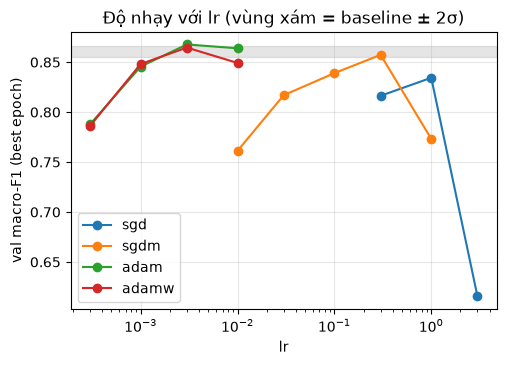

In [8]:
OPT_GRID = {"sgd": [0.3, 1.0, 3.0], "adam": [3e-4, 1e-3, 3e-3, 1e-2], "adamw": [3e-4, 1e-3, 3e-3, 1e-2]}
NAMES = {"sgd": "SGD", "adam": "Adam", "adamw": "AdamW"}
for name, lrs in OPT_GRID.items():
    for lr in lrs:
        wd = 0.01 if name == "adamw" else 0.0
        run_and_log(mk(f"opt-{name}-lr{lrtag(lr)}", "optimizer",
                       f"{NAMES[name]} lr={lr:g}" + (", weight_decay=0.01" if wd else ""),
                       optimizer=name, lr=lr, weight_decay=wd))
run_and_log(mk("opt-adamw-wd0-lr3e-3", "optimizer", "AdamW weight_decay=0, lr=3e-3 (kiểm chứng AdamW≡Adam)",
               optimizer="adamw", lr=3e-3, weight_decay=0.0))
a, b = RESULTS["opt-adam-lr3e-3"]["summary"], RESULTS["opt-adamw-wd0-lr3e-3"]["summary"]
print("\nAdam(3e-3) vs AdamW(wd=0, 3e-3): val_loss", a["best_val_loss"], b["best_val_loss"], "| macro-F1", a["val_macro_f1"], b["val_macro_f1"])

opt_runs = {"sgd": [f"opt-sgd-lr{lrtag(l)}" for l in OPT_GRID["sgd"]],
            "sgdm": [f"opt-sgdm-lr{lrtag(l)}" for l in SGDM_LRS],
            "adam": [f"opt-adam-lr{lrtag(l)}" for l in OPT_GRID["adam"]],
            "adamw": [f"opt-adamw-lr{lrtag(l)}" for l in OPT_GRID["adamw"]]}
best_of = {k: max(v, key=lambda i: RESULTS[i]["summary"]["val_macro_f1"]) for k, v in opt_runs.items()}
display(table([i for v in opt_runs.values() for i in v] + ["opt-adamw-wd0-lr3e-3"]))
print("lr tốt nhất của từng bộ tối ưu (theo val macro-F1):", best_of)
plot_compare([RESULTS[best_of[k]] for k in opt_runs], ["val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_optimizer.png", "Mỗi bộ tối ưu ở lr tốt nhất của nó (val)",
             labels=[f"{k} ({best_of[k]})" for k in opt_runs])
# độ nhạy với lr
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for k, v in opt_runs.items():
    ax.plot([RESULTS[i]["cfg"]["lr"] for i in v], [RESULTS[i]["summary"]["val_macro_f1"] for i in v], "o-", label=k)
ax.set_xscale("log"); ax.set_xlabel("lr"); ax.set_ylabel("val macro-F1 (best epoch)"); ax.grid(alpha=.3); ax.legend()
ax.axhspan(F1_MEAN - NOISE2, F1_MEAN + NOISE2, color="gray", alpha=.2, label="baseline ± 2σ")
ax.set_title("Độ nhạy với lr (vùng xám = baseline ± 2σ)"); fig.savefig(f"{OUT_DIR}/figures/compare_optimizer_lr_sensitivity.png", dpi=110, bbox_inches="tight"); plt.show()

**Đối chiếu:** ở lr tốt nhất của từng bộ: SGD (lr 1.0) 0.834 < SGD+momentum (0.3) 0.857 < AdamW (3e-3, wd 0.01) 0.865 < Adam (3e-3) 0.868. Chỉ SGD thuần kém hơn rõ (vượt 2σ); Adam hơn trung bình baseline 0.007, sát ngưỡng 2σ = 0.006 với 1 seed ⇒ chưa đủ để khẳng định. SGD thuần tốt nhất ở lr ≈ 3× (không phải 10×) SGD+momentum. Adam giữ ≥ 0.845 trên 3 giá trị lr liền nhau, SGD+momentum chỉ ở 1 giá trị ⇒ Adam ít nhạy lr hơn (đúng dự đoán) vì bước được chia theo √v̂ từng tham số. AdamW(wd=0) cho đúng cùng số với Adam (val loss 0.2145, macro-F1 0.8677). Nếu không chỉnh lr (Adam 1e-3 = 0.846 so với SGD+mom 0.01 = 0.761) thì kết luận "Adam thắng" bị phóng đại tới 0.085.

### Chủ đề 1 — Hàm mất mát (`loss`): cross-entropy vs MSE
MSE ở đây = `F.mse_loss(logit, one_hot)`, trung bình trên **mọi phần tử** (B×7), không hệ số 1/2 (như `nn.MSELoss`). **Không so loss trực tiếp** — so val acc, macro-F1 và tốc độ hội tụ.

**Dự đoán trước:** MSE trên logit cho gradient `2(z−y)/(7B)` — nhỏ hơn CE (`p−y`, /B) và không "phạt" mạnh khi tự tin sai ⇒ học chậm hơn ở cùng lr
và kém hơn về macro-F1 (lớp hiếm ít được kéo). Tăng lr có thể bù một phần. Thử MSE ở lr {0.1, 0.3 (=baseline), 1.0}.

In [9]:
for lr in (0.1, 0.3, 1.0):
    run_and_log(mk(f"loss-mse-lr{lrtag(lr)}", "loss", f"MSE trên one-hot, lr={lr:g}", loss="mse", lr=lr))
display(table([f"loss-mse-lr{lrtag(l)}" for l in (0.1, 0.3, 1.0)]))
best_mse = max([f"loss-mse-lr{lrtag(l)}" for l in (0.1, 0.3, 1.0)], key=lambda i: RESULTS[i]["summary"]["val_macro_f1"])
plot_compare([B1, RESULTS["loss-mse-lr0.3"], RESULTS[best_mse]], ["val_acc", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_loss.png", "CE (baseline) vs MSE — so acc/macro-F1, không so loss")

loss-mse-lr0.1             lr=0.1     step0=0.636 best_ep=  20 val_loss=0.0293 acc=0.8705 macroF1=0.7277 t/ep=2.19s diverged=N [đọc lại từ results/]


loss-mse-lr0.3             lr=0.3     step0=0.636 best_ep=  20 val_loss=0.0274 acc=0.8803 macroF1=0.7726 t/ep=2.22s diverged=N [đọc lại từ results/]


loss-mse-lr1               lr=1       step0=0.636 best_ep=  20 val_loss=0.0454 acc=0.7956 macroF1=0.5991 t/ep=2.18s diverged=N [đọc lại từ results/]


,lr,best_ep,val_loss,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,gap_val_train,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,
loss-mse-lr0.1,0.1,20,0.0293,0.8705,0.7277,-0.1330,Có,0.0009,2.1898,175.6729,N
loss-mse-lr0.3,0.3,20,0.0274,0.8803,0.7726,-0.0881,Có,0.0010,2.2231,175.8560,N
loss-mse-lr1,1.0,20,0.0454,0.7956,0.5991,-0.2616,Có,0.0002,2.1800,176.0391,N


**Đối chiếu:** đúng dự đoán. MSE tốt nhất ở lr 0.3 chỉ đạt val macro-F1 0.773 (acc 0.880) so với CE 0.857–0.863; Δ ≈ −0.088 ≫ 2σ. MSE cũng chậm hơn: macro-F1 ở epoch 1/5/9/13/17 là 0.48/0.66/0.70/0.74/0.77 so với 0.60/0.80/0.82/0.84/0.85 của CE. Tăng lr lên 1.0 không bù được (0.599, grad_norm max 14). Cơ chế: gradient CE theo logit là p−y (lớn khi sai nặng), còn MSE là 2(z−y)/(7B), nhỏ và chia đều cho mọi logit nên lớp hiếm ít được kéo lên.

### Chủ đề 3 — Hyper-parameter (`hparam`)
Yếu tố đổi (mỗi lần một): batch 128 và 2048 (kèm lr theo quy tắc tuyến tính: lô ×k ⇒ lr ×k), `M-wide`, `M-deep`, `weight_decay=1e-4` (L2 trong SGD), 40 epoch.
Nhớ: cùng số epoch nhưng batch khác ⇒ **số bước cập nhật khác** (372 k mẫu: batch 128 → 2 905 bước/epoch; 512 → 727; 2048 → 182).

**Dự đoán trước:** batch 128 ở lr 0.3 quá lớn so với nhiễu gradient (dao động) nên lr/4=0.075 tốt hơn, và tốn thời gian/epoch gấp ~3–4 lần; batch 2048 ít bước hơn nên kém hơn ở lr 0.3, còn
lr×4=1.2 theo quy tắc tuyến tính mà không khởi động có thể bất ổn; `M-wide`/`M-deep` hơn baseline (baseline còn chưa hội tụ, năng lực là điểm nghẽn, chưa quá khớp);
`wd=1e-4` không giúp (chưa quá khớp); 40 epoch hơn 20 epoch (baseline có best epoch ở gần cuối).

In [10]:
run_and_log(mk("hp-b128-lr0.3", "hparam", "batch 128 (giữ lr 0.3)", batch=128))
run_and_log(mk("hp-b128-lr0.075", "hparam", "batch 128, lr=0.3/4 (quy tắc tuyến tính)", batch=128, lr=0.075))
run_and_log(mk("hp-b2048-lr0.3", "hparam", "batch 2048 (giữ lr 0.3)", batch=2048))
run_and_log(mk("hp-b2048-lr1.2", "hparam", "batch 2048, lr=0.3×4 (quy tắc tuyến tính, không khởi động)", batch=2048, lr=1.2))
run_and_log(mk("hp-wide", "hparam", "M-wide 54-512-256-7 (161 287 tham số)", hidden=(512, 256)))
run_and_log(mk("hp-deep", "hparam", "M-deep 54-256-128-64-7 (55 687 tham số)", hidden=(256, 128, 64)))
run_and_log(mk("hp-wd1e-4", "hparam", "weight_decay=1e-4 (L2 trong SGD)", weight_decay=1e-4))
run_and_log(mk("hp-ep40", "hparam", "40 epoch thay vì 20", notes="epochs=40 (khác 20 của các thí nghiệm khác)", epochs=40))
hp_ids = ["hp-b128-lr0.3", "hp-b128-lr0.075", "hp-b2048-lr0.3", "hp-b2048-lr1.2", "hp-wide", "hp-deep", "hp-wd1e-4", "hp-ep40"]
display(table(hp_ids))
plot_compare([B1] + [RESULTS[i] for i in hp_ids[:4]], ["val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_hparam_batch.png", "Batch size (val) — số bước/epoch khác nhau")
plot_compare([B1] + [RESULTS[i] for i in hp_ids[4:]], ["val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_hparam_other.png", "Độ rộng / độ sâu / weight decay / số epoch (val)")

hp-b128-lr0.3              lr=0.3     step0=2.269 best_ep=  14 val_loss=0.3209 acc=0.8749 macroF1=0.7951 t/ep=8.46s diverged=N [đọc lại từ results/]


hp-b128-lr0.075            lr=0.075   step0=2.269 best_ep=  20 val_loss=0.2149 acc=0.9161 macroF1=0.8647 t/ep=8.29s diverged=N [đọc lại từ results/]


hp-b2048-lr0.3             lr=0.3     step0=2.269 best_ep=  18 val_loss=0.2437 acc=0.9014 macroF1=0.8338 t/ep=0.56s diverged=N [đọc lại từ results/]


hp-b2048-lr1.2             lr=1.2     step0=2.269 best_ep=  11 val_loss=1.2052 acc=0.4876 macroF1=0.0936 t/ep=0.55s diverged=N [đọc lại từ results/]


hp-wide                    lr=0.3     step0=1.918 best_ep=  20 val_loss=0.1998 acc=0.9226 macroF1=0.8747 t/ep=2.18s diverged=N [đọc lại từ results/]


hp-deep                    lr=0.3     step0=1.910 best_ep=  20 val_loss=0.2222 acc=0.9138 macroF1=0.8413 t/ep=2.46s diverged=N [đọc lại từ results/]


hp-wd1e-4                  lr=0.3     step0=2.269 best_ep=  18 val_loss=0.2823 acc=0.8853 macroF1=0.8123 t/ep=2.20s diverged=N [đọc lại từ results/]


hp-ep40                    lr=0.3     step0=2.269 best_ep=  32 val_loss=0.1995 acc=0.9232 macroF1=0.8733 t/ep=2.19s diverged=N [đọc lại từ results/]


,lr,best_ep,val_loss,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,gap_val_train,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,
hp-b128-lr0.3,0.300,14,0.3209,0.8749,0.7951,-0.0656,Có,0.0200,8.4558,176.1880,N
hp-b128-lr0.075,0.075,20,0.2149,0.9161,0.8647,0.0040,Không,0.0277,8.2921,176.3711,N
hp-b2048-lr0.3,0.300,18,0.2437,0.9014,0.8338,-0.0269,Có,0.0193,0.5609,178.1128,N
hp-b2048-lr1.2,1.200,11,1.2052,0.4876,0.0936,-0.7671,Có,0.0017,0.5502,176.8311,N
hp-wide,0.300,20,0.1998,0.9226,0.8747,0.0140,Có,0.0328,2.1841,195.0190,N
hp-deep,0.300,20,0.2222,0.9138,0.8413,-0.0195,Có,0.0309,2.4644,178.9951,N
hp-wd1e-4,0.300,18,0.2823,0.8853,0.8123,-0.0484,Có,0.0144,2.2013,179.0874,N
hp-ep40,0.300,32,0.1995,0.9232,0.8733,0.0126,Có,0.0357,2.1912,179.2705,N


**Đối chiếu:** batch 128 với lr 0.3 dao động (best epoch 14, 0.795); hạ lr theo tỉ lệ (0.075) cho 0.865 (trong nhiễu) nhưng tốn ≈ 4× thời gian/epoch. Batch 2048 (lr 0.3) kém (0.834, chỉ 182 bước/epoch); tăng lr ×4 không khởi động làm mạng sụp về đoán lớp đa số (0.094). M-wide (0.875) và 40 epoch (0.873) vượt 2σ, đúng dự đoán vì baseline chưa hội tụ. **Không như dự đoán:** M-deep tệ hơn (0.841) và weight decay 1e-4 hại nhiều (0.812); lý do khả dĩ là lr 0.3 chưa hợp với mạng 3 lớp ẩn và L2 làm co trọng số khi mạng còn chưa khớp — chưa kiểm chứng thêm.

### Chủ đề 4 — Dropout (`dropout`), `q ∈ {0.1, 0.3, 0.5}`
**Dự đoán trước:** baseline *chưa quá khớp* (khoảng cách val−train loss nhỏ, val vẫn giảm đến cuối) nên dropout **không giúp**: nó thêm nhiễu và giảm năng lực hiệu dụng ⇒ q càng lớn
càng tụt (underfitting), nhất là macro-F1 của lớp hiếm. Train loss được đo ở `eval()` nên dropout không làm train loss "tăng giả".

In [11]:
for q in (0.1, 0.3, 0.5):
    run_and_log(mk(f"drop-{q}", "dropout", f"Dropout q={q} sau mỗi ReLU lớp ẩn", dropout=q))
d_ids = [f"drop-{q}" for q in (0.1, 0.3, 0.5)]
display(table(["base-s1"] + d_ids))
plot_compare([B1] + [RESULTS[i] for i in d_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_dropout.png", "Dropout: train loss (eval mode), val loss, val macro-F1")

drop-0.1                   lr=0.3     step0=2.269 best_ep=  20 val_loss=0.2400 acc=0.9025 macroF1=0.8385 t/ep=2.36s diverged=N [đọc lại từ results/]


drop-0.3                   lr=0.3     step0=2.269 best_ep=  20 val_loss=0.3141 acc=0.8720 macroF1=0.7824 t/ep=2.32s diverged=N [đọc lại từ results/]


drop-0.5                   lr=0.3     step0=2.269 best_ep=  20 val_loss=0.4249 acc=0.8196 macroF1=0.5784 t/ep=2.35s diverged=N [đọc lại từ results/]


,lr,best_ep,val_loss,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,gap_val_train,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,
base-s1,0.3,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,2.1210,174.2046,N
drop-0.1,0.3,20,0.2400,0.9025,0.8385,-0.0222,Có,0.0147,2.3642,179.4536,N
drop-0.3,0.3,20,0.3141,0.8720,0.7824,-0.0783,Có,0.0059,2.3205,179.6367,N
drop-0.5,0.3,20,0.4249,0.8196,0.5784,-0.2823,Có,0.0039,2.3479,179.8198,N


**Đối chiếu:** đúng dự đoán. Khoảng cách val−train loss giảm từ 0.028 (baseline) xuống 0.015 / 0.006 / 0.004 với q = 0.1 / 0.3 / 0.5, nhưng val macro-F1 tụt còn 0.839 / 0.782 / 0.578 (đều vượt 2σ). Khoảng cách thu hẹp vì train loss tệ đi (underfitting), không phải vì val tốt lên: không có quá khớp để chữa.

### Chủ đề 5 — Cắt gradient (`clipping`)
`g ← g·min(1, c/‖g‖)`, `‖g‖` = chuẩn L2 toàn cục; `grad_norm` được ghi **trước** clip. Chọn `c` **sau khi nhìn `grad_norm` của baseline**:

In [12]:
h = B1["history"]
print("baseline: grad_norm TB mỗi epoch  :", np.round(h["grad_norm"], 2))
print("baseline: grad_norm MAX mỗi epoch :", np.round(h["grad_norm_max"], 2))
print(f"=> grad_norm điển hình ≈ {np.median(h['grad_norm']):.2f}, gai lên tới {max(h['grad_norm_max']):.1f}")

baseline: grad_norm TB mỗi epoch  : [0.38 0.37 0.37 0.37 0.36 0.36 0.36 0.36 0.36 0.35 0.35 0.35 0.35 0.34
 0.34 0.34 0.34 0.34 0.34 0.34]
baseline: grad_norm MAX mỗi epoch : [2.84 0.64 0.67 0.71 0.56 0.72 0.64 0.59 0.55 0.63 0.54 0.71 0.63 0.56
 0.64 0.59 0.86 0.52 0.57 0.66]
=> grad_norm điển hình ≈ 0.35, gai lên tới 2.8


Chọn `c ∈ {1.0, 0.5, 0.3}`: `c=1.0` lớn hơn grad_norm điển hình vài lần nên chỉ cắt các "gai"; `c=0.5` ≈ mức điển hình; `c=0.3` thấp hơn mức điển hình nên cắt gần như mọi bước.

**Dự đoán trước:** (a) ở lr 0.3 (huấn luyện ổn định), `c=1.0` gần như không kích hoạt ⇒ kết quả ≈ baseline (chênh lệch trong nhiễu); `c` nhỏ kích hoạt ở mọi bước ⇒ tương đương giảm lr hiệu dụng ⇒ chậm hơn/kém hơn;
(b) **thí nghiệm phản chứng:** ở lr rất cao (1.0 và 3.0, momentum 0.9) huấn luyện không clip dao động/sụp đổ do gradient đột ngột lớn; cùng lr có clip sẽ giữ bước cập nhật bị chặn ⇒ ổn định, tốt hơn rõ rệt.
Với lr 1.0 dùng lại `opt-sgdm-lr1` (không clip) làm đối chứng.

In [13]:
ctag = lambda c: f"c{c:g}"
for c in (1.0, 0.5, 0.3):
    run_and_log(mk(f"clip-{ctag(c)}-lr0.3", "clipping", f"clip_norm c={c:g}, lr=0.3 (ổn định)", clip_norm=c))
for c in (1.0, 0.3):
    run_and_log(mk(f"clip-{ctag(c)}-lr1", "clipping", f"clip_norm c={c:g}, lr=1.0", clip_norm=c, lr=1.0))
run_and_log(mk("clip-none-lr3", "clipping", "KHÔNG clip, lr=3.0 (lr rất cao)", lr=3.0))
for c in (1.0, 0.3):
    run_and_log(mk(f"clip-{ctag(c)}-lr3", "clipping", f"clip_norm c={c:g}, lr=3.0", clip_norm=c, lr=3.0))
c_ids = ["clip-c1-lr0.3", "clip-c0.5-lr0.3", "clip-c0.3-lr0.3", "opt-sgdm-lr1", "clip-c1-lr1", "clip-c0.3-lr1",
         "clip-none-lr3", "clip-c1-lr3", "clip-c0.3-lr3"]
tb = table(c_ids)
tb["clip_frac"] = [np.mean(RESULTS[i]["history"]["clip_frac"]).round(3) for i in c_ids]
tb["gn_max"] = [max(RESULTS[i]["history"]["grad_norm_max"]) for i in c_ids]
display(tb[["lr", "best_ep", "val_acc", "val_f1", "d_f1_vs_base", "beyond_2sigma", "clip_frac", "gn_max", "diverged"]])
plot_compare([B1] + [RESULTS[i] for i in c_ids[:3]], ["val_loss", "val_macro_f1", "clip_frac"],
             f"{OUT_DIR}/figures/compare_clipping_lr0.3.png", "Clipping ở lr ổn định (0.3): c = 1.0 / 0.5 / 0.3")
plot_compare([RESULTS[i] for i in ("clip-none-lr3", "clip-c1-lr3", "clip-c0.3-lr3", "opt-sgdm-lr1", "clip-c1-lr1", "clip-c0.3-lr1")],
             ["val_loss", "val_macro_f1", "grad_norm_max"], f"{OUT_DIR}/figures/compare_clipping_highlr.png",
             "Clipping ở lr cao (1.0 và 3.0): có / không clip")

clip-c1-lr0.3              lr=0.3     step0=2.269 best_ep=  20 val_loss=0.2237 acc=0.9129 macroF1=0.8534 t/ep=2.26s diverged=N [đọc lại từ results/]


clip-c0.5-lr0.3            lr=0.3     step0=2.269 best_ep=  20 val_loss=0.2279 acc=0.9100 macroF1=0.8481 t/ep=2.20s diverged=N [đọc lại từ results/]


clip-c0.3-lr0.3            lr=0.3     step0=2.269 best_ep=  18 val_loss=0.2333 acc=0.9079 macroF1=0.8311 t/ep=2.23s diverged=N [đọc lại từ results/]


clip-c1-lr1                lr=1       step0=2.269 best_ep=  14 val_loss=0.3148 acc=0.8772 macroF1=0.8106 t/ep=2.18s diverged=N [đọc lại từ results/]


clip-c0.3-lr1              lr=1       step0=2.269 best_ep=  20 val_loss=0.2887 acc=0.8918 macroF1=0.8297 t/ep=2.27s diverged=N [đọc lại từ results/]


clip-none-lr3              lr=3       step0=2.269 best_ep=  17 val_loss=1.2090 acc=0.4876 macroF1=0.0936 t/ep=2.11s diverged=N [đọc lại từ results/]


clip-c1-lr3                lr=3       step0=2.269 best_ep=  17 val_loss=1.2090 acc=0.4876 macroF1=0.0936 t/ep=2.30s diverged=N [đọc lại từ results/]


clip-c0.3-lr3              lr=3       step0=2.269 best_ep=   2 val_loss=0.9319 acc=0.6077 macroF1=0.1875 t/ep=2.25s diverged=N [đọc lại từ results/]


,lr,best_ep,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,clip_frac,gn_max,diverged
exp_id,,,,,,,,,
clip-c1-lr0.3,0.3,20,0.9129,0.8534,-0.0073,Có,0.001,2.843747,N
clip-c0.5-lr0.3,0.3,20,0.9100,0.8481,-0.0126,Có,0.014,2.843747,N
clip-c0.3-lr0.3,0.3,18,0.9079,0.8311,-0.0296,Có,0.995,2.843747,N
opt-sgdm-lr1,1.0,19,0.8662,0.7732,-0.0875,Có,0.000,9.701719,N
clip-c1-lr1,1.0,14,0.8772,0.8106,-0.0501,Có,0.000,3.590464,N
clip-c0.3-lr1,1.0,20,0.8918,0.8297,-0.0310,Có,0.096,2.843747,N
clip-none-lr3,3.0,17,0.4876,0.0936,-0.7671,Có,0.000,7813.538086,N
clip-c1-lr3,3.0,17,0.4876,0.0936,-0.7671,Có,0.001,10.096516,N
clip-c0.3-lr3,3.0,2,0.6077,0.1875,-0.6732,Có,0.063,18.082024,N


**Đối chiếu:** ở lr 0.3, c = 1.0 chỉ cắt 0.1% số bước (gần như chỉ ở epoch đầu) và kết quả nằm trong nhiễu (0.853); c = 0.3 cắt 99.5% số bước, tương đương giảm lr hiệu dụng ⇒ kém hơn (0.831). Ở lr 1.0, clip cải thiện rõ: 0.773 → 0.811 (c = 1.0) và 0.830 (c = 0.3), vượt 2σ. **Không như dự đoán:** ở lr 3.0 clip không cứu được (0.094 và 0.188): clip chặn chuẩn gradient nhưng bước cập nhật vẫn là lr·c/(1−μ), quá lớn; sau gai đầu tiên (grad_norm max 7 813) val loss đứng ở ≈ 1.209 ≈ entropy phân phối lớp, tức mạng chỉ còn học tần suất lớp.

### Chủ đề 6 — Mixed precision (`amp`)
FP16: `autocast(float16)` + `GradScaler` (có `unscale_` trước khi đo/clip gradient). BF16: `autocast(bfloat16)`, không cần GradScaler. Tham số vẫn FP32; đánh giá val luôn FP32.
FP16 hẹp về khoảng giá trị (max ≈ 6.5e4, số dưới chuẩn ≈ 6e-8) nên gradient nhỏ dễ underflow → cần nhân loss với hệ số `s`; BF16 có cùng 8 bit mũ với FP32 (khoảng giá trị rộng) nhưng chỉ 8 bit mantissa nên không cần scaler.
T4 (compute 7.5) có Tensor Core FP16 nhưng **không có BF16 phần cứng** (`is_bf16_supported()` vẫn trả True vì được giả lập).

**Dự đoán trước:** với mạng nhỏ này (vài chục nghìn tham số, batch 512) thời gian bị chi phối bởi chi phí gọi kernel/Python, còn autocast thêm các phép cast ⇒ FP16 **không nhanh hơn**
(có thể chậm hơn); BF16 trên T4 còn chậm hơn FP16; bộ nhớ cực đại gần như không đổi (dữ liệu nằm sẵn trên GPU chiếm phần lớn); độ chính xác ≈ FP32 (trong nhiễu).
Thử thêm mạng rất rộng `2048-2048` (3 epoch, chỉ để đo tốc độ/bộ nhớ): ở đây FP16 mới có thể có lợi.

In [14]:
if device == "cuda":
    print(torch.cuda.get_device_name(0), "| compute capability:", torch.cuda.get_device_capability(0),
          "| is_bf16_supported():", torch.cuda.is_bf16_supported())
run_and_log(mk("amp-fp16", "amp", "FP16 autocast + GradScaler", precision="fp16"))
run_and_log(mk("amp-bf16", "amp", "BF16 autocast (không scaler)", precision="bf16",
               notes="T4 không có BF16 phần cứng (giả lập)"))
BIG = dict(hidden=(2048, 2048), epochs=3, notes="mạng 2048-2048 (ngoài bảng kiến trúc) và 3 epoch, chỉ để đo tốc độ/bộ nhớ")
run_and_log(mk("amp-big-fp32", "amp", "2048-2048, FP32 (đối chứng tốc độ)", **BIG))
run_and_log(mk("amp-big-fp16", "amp", "2048-2048, FP16", precision="fp16", **BIG))
run_and_log(mk("amp-big-bf16", "amp", "2048-2048, BF16", precision="bf16", **BIG))
a_ids = ["base-s1", "amp-fp16", "amp-bf16", "amp-big-fp32", "amp-big-fp16", "amp-big-bf16"]
display(table(a_ids)[["val_loss", "val_acc", "val_f1", "d_f1_vs_base", "beyond_2sigma", "s_per_ep", "mem_MB", "diverged"]])
plot_compare([B1, RESULTS["amp-fp16"], RESULTS["amp-bf16"]], ["val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_amp.png", "FP32 vs FP16 vs BF16 (M-base, val)")

NVIDIA GeForce RTX 4050 Laptop GPU | compute capability: (8, 9) | is_bf16_supported(): True


amp-fp16                   lr=0.3     step0=2.269 best_ep=  20 val_loss=0.2327 acc=0.9082 macroF1=0.8502 t/ep=3.04s diverged=N [đọc lại từ results/]


amp-bf16                   lr=0.3     step0=2.269 best_ep=  18 val_loss=0.2295 acc=0.9097 macroF1=0.8506 t/ep=2.59s diverged=N [đọc lại từ results/]


amp-big-fp32               lr=0.3     step0=2.242 best_ep=   3 val_loss=0.2823 acc=0.8828 macroF1=0.8082 t/ep=6.93s diverged=N [đọc lại từ results/]


amp-big-fp16               lr=0.3     step0=2.242 best_ep=   3 val_loss=0.2897 acc=0.8806 macroF1=0.7993 t/ep=3.42s diverged=N [đọc lại từ results/]


amp-big-bf16               lr=0.3     step0=2.242 best_ep=   3 val_loss=0.2907 acc=0.8805 macroF1=0.8013 t/ep=9.71s diverged=N [đọc lại từ results/]


,val_loss,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,
base-s1,0.2318,0.9090,0.8573,-0.0034,Không,2.1210,174.2046,N
amp-fp16,0.2327,0.9082,0.8502,-0.0105,Có,3.0360,181.4526,N
amp-bf16,0.2295,0.9097,0.8506,-0.0101,Có,2.5895,181.6348,N
amp-big-fp32,0.2823,0.8828,0.8082,-0.0525,Có,6.9318,358.0884,N
amp-big-fp16,0.2897,0.8806,0.7993,-0.0614,Có,3.4238,374.5801,N
amp-big-bf16,0.2907,0.8805,0.8013,-0.0594,Có,9.7139,391.0718,N


**Đối chiếu:** độ chính xác FP16 (0.850) và BF16 (0.851) thấp hơn FP32 seed 1 (0.857) khoảng 0.007 — cỡ ngưỡng 2σ với 1 seed nên không kết luận được AMP làm giảm chất lượng. Bộ nhớ cực đại gần như không đổi (≈ 174 → 181 MB) vì dữ liệu nằm sẵn trên GPU chiếm phần lớn. Về tốc độ: với M-base, FP16/BF16 không nhanh hơn FP32; với mạng 2048-2048, FP16 nhanh hơn rõ (≈ 2×) còn BF16 chậm nhất do T4 không có BF16 phần cứng. Thời gian/epoch được đo khi GPU không dành riêng cho tiến trình này nên chỉ dùng để so sánh tương đối, không làm số tuyệt đối.

### Chủ đề 7 — Khởi tạo tham số (`init`)
`zeros` (W=0), `normal` (N(0, 0.01²)), `xavier` (`xavier_normal_`, Var = 2/(n_in+n_out) — **khác** Var = 1/n_in của slide), `he` (baseline), thêm `default` (mặc định `nn.Linear`: Kaiming-uniform a=√5, KHÔNG phải He). Bias = 0 (trừ `default`).

**Dự đoán trước:** `zeros`: logit = 0 nên loss bước 0 = ln 7 chính xác; ReLU(0) = 0 và mọi nơ-ron đối xứng ⇒ gradient của W1, W2, W3 bằng 0, chỉ bias lớp cuối nhận gradient ⇒ mạng chỉ học tần suất lớp
(đoán lớp đa số: acc ≈ 0.4876, macro-F1 ≈ 0.094). `normal` 0.01: kích hoạt co dần qua các lớp (std rất nhỏ ở logit) nên gradient nhỏ lúc đầu, nhưng mạng chỉ 3 lớp vẫn học được.
`xavier`/`he`/`default`: khác biệt nhỏ ở mạng nông (trong nhiễu). Độ lệch chuẩn kích hoạt ở bước 0: He giữ ổn định qua lớp ReLU; `normal` co lại; `xavier` hơi co (thiếu hệ số 2 cho ReLU).

,step0_loss,std_after_L1,std_after_L2,std_logits,gradW1,gradW2,gradW3,gradb3
init,,,,,,,,
zeros,1.94591,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.49671
normal,1.94600,0.03434,0.00376,0.00027,0.00395,0.00710,0.00990,0.49674
xavier,2.02218,0.27584,0.21822,0.19156,0.36071,0.72909,0.59931,0.51772
he,2.26906,0.66090,0.64036,0.57728,0.50705,2.02123,1.96046,0.57246
default,1.98304,0.27370,0.11298,0.05851,0.07849,0.34652,0.33901,0.50832


(std_after_Lk = độ lệch chuẩn đầu ra SAU nn.Linear thứ k, trước ReLU; trên một lô 4096 mẫu val)


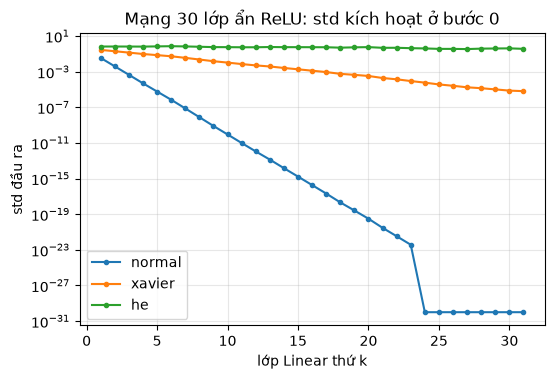

In [15]:
INITS = ["zeros", "normal", "xavier", "he", "default"]
rows = []
for ini in INITS:
    set_seed(1); m = MLP(init=ini).to(device)
    stds = activation_stats(m, X_val[:4096])
    l0 = evaluate(m, X_val, y_val)["loss"]
    loss = compute_loss(m(X_tr[:512]), y_tr[:512], "ce"); loss.backward()
    gn = [p.grad.norm().item() for p in m.parameters()]
    rows.append(dict(init=ini, step0_loss=l0, std_after_L1=stds[0], std_after_L2=stds[1], std_logits=stds[2],
                     gradW1=gn[0], gradW2=gn[2], gradW3=gn[4], gradb3=gn[5]))
display(pd.DataFrame(rows).set_index("init").round(5))
print("(std_after_Lk = độ lệch chuẩn đầu ra SAU nn.Linear thứ k, trước ReLU; trên một lô 4096 mẫu val)")

# minh hoạ kiểu slide: mạng RẤT sâu (30 lớp ẩn, rộng 256), std kích hoạt theo độ sâu ở bước 0
fig, ax = plt.subplots(figsize=(6, 3.8))
for ini in ("normal", "xavier", "he"):
    set_seed(1); deep = MLP(hidden=(256,) * 30, init=ini).to(device)
    s = activation_stats(deep, X_val[:4096]); ax.semilogy(range(1, len(s) + 1), np.maximum(s, 1e-30), "o-", ms=3, label=ini)
ax.set_xlabel("lớp Linear thứ k"); ax.set_ylabel("std đầu ra"); ax.set_title("Mạng 30 lớp ẩn ReLU: std kích hoạt ở bước 0"); ax.grid(alpha=.3); ax.legend()
fig.savefig(f"{OUT_DIR}/figures/compare_init_activation_depth30.png", dpi=110, bbox_inches="tight"); plt.show()

In [16]:
for ini in ("zeros", "normal", "xavier", "default"):
    run_and_log(mk(f"init-{ini}", "init", f"init={ini}", init=ini))
i_ids = ["base-s1", "init-zeros", "init-normal", "init-xavier", "init-default"]
display(table(i_ids)[["val_loss", "val_acc", "val_f1", "d_f1_vs_base", "beyond_2sigma", "best_ep"]])
print("step0_loss:", {i: round(RESULTS[i]["summary"]["step0_loss"], 4) for i in i_ids})
plot_compare([RESULTS[i] for i in i_ids], ["val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_init.png", "Khởi tạo tham số (baseline = he)")

init-zeros                 lr=0.3     step0=1.946 best_ep=  16 val_loss=1.2053 acc=0.4876 macroF1=0.0936 t/ep=2.19s diverged=N [đọc lại từ results/]


init-normal                lr=0.3     step0=1.946 best_ep=  20 val_loss=0.2204 acc=0.9137 macroF1=0.8609 t/ep=2.23s diverged=N [đọc lại từ results/]


init-xavier                lr=0.3     step0=2.022 best_ep=  18 val_loss=0.2236 acc=0.9096 macroF1=0.8502 t/ep=2.17s diverged=N [đọc lại từ results/]


init-default               lr=0.3     step0=1.983 best_ep=  20 val_loss=0.2170 acc=0.9145 macroF1=0.8637 t/ep=2.16s diverged=N [đọc lại từ results/]


,val_loss,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,best_ep
exp_id,,,,,,
base-s1,0.2318,0.9090,0.8573,-0.0034,Không,19
init-zeros,1.2053,0.4876,0.0936,-0.7671,Có,16
init-normal,0.2204,0.9137,0.8609,0.0002,Không,20
init-xavier,0.2236,0.9096,0.8502,-0.0105,Có,18
init-default,0.2170,0.9145,0.8637,0.0029,Không,20


step0_loss: {'base-s1': 2.2691, 'init-zeros': 1.9459, 'init-normal': 1.946, 'init-xavier': 2.0222, 'init-default': 1.983}


**Đối chiếu:** `zeros` đúng dự đoán: loss bước 0 = 1.9459 = ln 7, val loss dừng ở ≈ 1.205 = entropy phân phối lớp, acc 0.4876 và macro-F1 0.094 — mạng chỉ học bias lớp cuối, grad_norm ≈ 0.04. `normal` (0.861), `default` (0.864), `xavier` (0.850) và `he` (0.857–0.863) đều trong khoảng ±0.011 quanh baseline; mạng 3 lớp quá nông để thấy khác biệt He/Xavier rõ như biểu đồ 30 lớp (ở mạng 30 lớp, std kích hoạt của `normal` co về ~0, `xavier` co dần, `he` giữ ổn định).

## Part 4 — Cấu hình cuối cùng, đánh giá trên eval, bảng và nộp bài
**Chọn cấu hình cuối cùng CHỈ bằng val.** Kết hợp các yếu tố đã thấy có ích ở Part 3 (Adam ở lr tốt nhất, mạng rộng `M-wide`, lịch lr cosine, thêm epoch) theo kiểu thêm dần từng yếu tố
(mỗi dòng đổi thêm một thứ so với dòng trước, seed 1), rồi chạy cấu hình thắng với 3 seed.
Dự đoán: Adam + M-wide + cosine hơn baseline > 0.02 macro-F1 (vượt xa 2σ): cosine hạ lr về 0 cuối huấn luyện nên giảm nhiễu SGD ở điểm cuối, còn M-wide tăng năng lực — baseline chưa quá khớp nên thêm năng lực không gây hại.

In [17]:
ADAM_LR = RESULTS[best_of["adam"]]["cfg"]["lr"]
FIN = dict(optimizer="adam", lr=ADAM_LR)
cands = [
    mk("fin-c1-adam-base-cos", "final", "ứng viên 1: Adam + cosine, M-base, 20 epoch", scheduler="cosine", notes="cosine annealing về 0 theo từng bước", **FIN),
    mk("fin-c2-adam-wide", "final", "ứng viên 2: Adam, M-wide, 20 epoch (lr hằng)", hidden=(512, 256), **FIN),
    mk("fin-c3-adam-wide-cos", "final", "ứng viên 3: Adam + cosine, M-wide, 20 epoch", hidden=(512, 256), scheduler="cosine", notes="cosine annealing về 0 theo từng bước", **FIN),
    mk("fin-c4-adam-wide-cos-ep40", "final", "ứng viên 4: Adam + cosine, M-wide, 40 epoch", hidden=(512, 256), scheduler="cosine", epochs=40, notes="cosine annealing; epochs=40", **FIN),
]
for c in cands:
    run_and_log(c)
cand_ids = [c["exp_id"] for c in cands]
display(table(["base-s1", best_of["adam"]] + cand_ids))
FINAL_ID = max(cand_ids, key=lambda i: RESULTS[i]["summary"]["val_macro_f1"])
print("CẤU HÌNH CUỐI CÙNG (chọn theo val macro-F1):", FINAL_ID)

fin-c1-adam-base-cos       lr=0.003   step0=2.269 best_ep=  20 val_loss=0.1918 acc=0.9242 macroF1=0.8826 t/ep=2.42s diverged=N [đọc lại từ results/]


fin-c2-adam-wide           lr=0.003   step0=1.918 best_ep=  20 val_loss=0.1822 acc=0.9285 macroF1=0.8914 t/ep=2.46s diverged=N [đọc lại từ results/]


fin-c3-adam-wide-cos       lr=0.003   step0=1.918 best_ep=  20 val_loss=0.1479 acc=0.9428 macroF1=0.9139 t/ep=2.51s diverged=N [đọc lại từ results/]


fin-c4-adam-wide-cos-ep40  lr=0.003   step0=1.918 best_ep=  39 val_loss=0.1231 acc=0.9541 macroF1=0.9267 t/ep=2.47s diverged=N [đọc lại từ results/]


,lr,best_ep,val_loss,val_acc,val_f1,d_f1_vs_base,beyond_2sigma,gap_val_train,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,
base-s1,0.300,19,0.2318,0.9090,0.8573,-0.0034,Không,0.0282,2.1210,174.2046,N
opt-adam-lr3e-3,0.003,19,0.2145,0.9153,0.8677,0.0070,Có,0.0290,2.3638,174.5708,N
fin-c1-adam-base-cos,0.003,20,0.1918,0.9242,0.8826,0.0219,Có,0.0253,2.4177,239.5537,N
fin-c2-adam-wide,0.003,20,0.1822,0.9285,0.8914,0.0307,Có,0.0335,2.4592,256.9302,N
fin-c3-adam-wide-cos,0.003,20,0.1479,0.9428,0.9139,0.0532,Có,0.0353,2.5064,257.5459,N
fin-c4-adam-wide-cos-ep40,0.003,39,0.1231,0.9541,0.9267,0.0660,Có,0.0535,2.4717,258.1616,N


CẤU HÌNH CUỐI CÙNG (chọn theo val macro-F1): fin-c4-adam-wide-cos-ep40


**Chọn cấu hình:** thêm dần từng yếu tố, val macro-F1: Adam+cosine (M-base) 0.883 → Adam (M-wide) 0.891 → Adam+cosine (M-wide) 0.914 → **Adam+cosine, M-wide, 40 epoch 0.927** ⇒ chọn `fin-c4-adam-wide-cos-ep40`. Cosine giảm lr về 0 nên giảm nhiễu SGD ở cuối; M-wide tăng năng lực khi mạng chưa quá khớp. Lưu ý: so với baseline đây là thay đổi nhiều yếu tố cùng lúc và gấp đôi số epoch.

In [18]:
FINAL_CFG = RESULTS[FINAL_ID]["cfg"]
# thêm 2 seed của cấu hình cuối cùng để đo nhiễu của chính nó (seed 1 = ứng viên đã chạy)
fin_runs = [FINAL_ID]
for s in (2, 3):
    r = run_and_log({**FINAL_CFG, "exp_id": f"final-s{s}", "seed": s, "group": "final",
                     "description": f"Cấu hình cuối cùng, seed {s}"})
    fin_runs.append(f"final-s{s}")
ff = np.array([RESULTS[i]["summary"]["val_macro_f1"] for i in fin_runs])
print(f"cấu hình cuối cùng: val macro-F1 = {ff.mean():.4f} ± {ff.std(ddof=1):.4f} (3 seed) | baseline = {F1_MEAN:.4f} ± {F1_STD:.4f}")
print(f"cải thiện trên val = {ff.mean() - F1_MEAN:+.4f} so với 2σ_baseline = {NOISE2:.4f}")
plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in fin_runs], ["val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_final.png", "Baseline vs cấu hình cuối cùng (val)")

final-s2                   lr=0.003   step0=2.652 best_ep=  40 val_loss=0.1254 acc=0.9532 macroF1=0.9254 t/ep=2.46s diverged=N [đọc lại từ results/]


final-s3                   lr=0.003   step0=2.788 best_ep=  40 val_loss=0.1250 acc=0.9536 macroF1=0.9272 t/ep=2.48s diverged=N [đọc lại từ results/]
cấu hình cuối cùng: val macro-F1 = 0.9264 ± 0.0010 (3 seed) | baseline = 0.8607 ± 0.0030
cải thiện trên val = +0.0657 so với 2σ_baseline = 0.0060


### Đánh giá trên tập eval (chỉ làm sau khi chốt cấu hình ở trên)
Nạp trọng số của **epoch có val loss thấp nhất**, dự đoán toàn bộ `X_eval` ở `eval()`/FP32, ghi `predictions_eval.csv` (cấu hình cuối cùng, seed 1) rồi chấm bằng đúng `scripts/evaluate.py`.
Baseline (`base-s1`) được chấm một lần để có cột `eval_*` của bảng (predictions của baseline chỉ nằm trong thư mục tạm).

In [19]:
def score(pred_csv, out_json):
    p = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", os.path.abspath(pred_csv), "--out", os.path.abspath(out_json)],
                       cwd=REPO_ROOT, capture_output=True, text=True)
    print(p.stdout[:400]); assert p.returncode == 0, p.stdout + p.stderr
    return json.load(open(out_json, encoding="utf-8"))

os.makedirs(f"{OUT_DIR}/results/eval", exist_ok=True)
# Trọng số không lưu ra đĩa. Nếu kết quả được đọc lại từ results/ mà file dự đoán/chấm điểm đã có thì dùng lại
# (chấm lại predictions_eval.csv bằng evaluate.py), không huấn luyện lại; trên runtime trắng thì huấn luyện + dự đoán.
BASE_JSON = f"{OUT_DIR}/results/eval/baseline_eval_result.json"
if RESULTS["base-s1"]["best_state"] is None and os.path.exists(BASE_JSON):
    EV_BASE = json.load(open(BASE_JSON, encoding="utf-8"))
    print("== BASELINE (base-s1) trên eval: đọc", BASE_JSON)
else:
    tmp = tempfile.mkdtemp()
    final_eval(RESULTS["base-s1"]["cfg"], ensure_state("base-s1"), data, f"{tmp}/baseline_predictions_eval.csv")
    print("== BASELINE (base-s1) trên eval =="); EV_BASE = score(f"{tmp}/baseline_predictions_eval.csv", BASE_JSON)
# cấu hình cuối cùng (seed 1) -> file nộp
if not (RESULTS[FINAL_ID]["best_state"] is None and os.path.exists(f"{OUT_DIR}/predictions_eval.csv")):
    final_eval(FINAL_CFG, ensure_state(FINAL_ID), data, f"{OUT_DIR}/predictions_eval.csv")
print(f"== CẤU HÌNH CUỐI CÙNG ({FINAL_ID}) trên eval =="); EV_FIN = score(f"{OUT_DIR}/predictions_eval.csv", f"{OUT_DIR}/eval_result.json")
print(f"\nbaseline : macro-F1 = {EV_BASE['macro_f1']:.4f}, acc = {EV_BASE['accuracy']:.4f}  (val macro-F1 {RESULTS['base-s1']['summary']['val_macro_f1']:.4f})")
print(f"cuối cùng: macro-F1 = {EV_FIN['macro_f1']:.4f}, acc = {EV_FIN['accuracy']:.4f}  (val macro-F1 {RESULTS[FINAL_ID]['summary']['val_macro_f1']:.4f})")
print(f"cải thiện eval macro-F1 = {EV_FIN['macro_f1'] - EV_BASE['macro_f1']:+.4f}")

== BASELINE (base-s1) trên eval: đọc ../results/eval/baseline_eval_result.json
== CẤU HÌNH CUỐI CÙNG (fin-c4-adam-wide-cos-ep40) trên eval ==


n_eval = 116203
accuracy = 0.9531
macro_f1 = 0.9294   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9524  0.9472  0.9498
  1    56661     0.9573  0.9632  0.9602
  2     7151     0.9539  0.9547  0.9543
  3      549     0.8969  0.8561  0.8760
  4     1899     0.9086  0.8794  0.8938
  5     3473     0.9200  0.9110  0.9155
  6     4102     0.9570  0.9559  0.9565

ma trận nh

baseline : macro-F1 = 0.8565, acc = 0.9089  (val macro-F1 0.8573)
cuối cùng: macro-F1 = 0.9294, acc = 0.9531  (val macro-F1 0.9267)
cải thiện eval macro-F1 = +0.0730


**Đánh giá trên eval:** baseline 0.8565 (acc 0.9089), cấu hình cuối **0.9294** (acc 0.9531); cải thiện +0.073 ≫ 2σ. Val và eval rất gần nhau (0.8573 vs 0.8565; 0.9267 vs 0.9294) nên val là ước lượng đáng tin của eval. Eval chỉ được chấm một lần cho mỗi cấu hình, sau khi cấu hình đã chốt.

,support,precision,recall,f1
0 Spruce/Fir,42368,0.9524,0.9472,0.9498
1 Lodgepole Pine,56661,0.9573,0.9632,0.9602
2 Ponderosa Pine,7151,0.9539,0.9547,0.9543
3 Cottonwood/Willow,549,0.8969,0.8561,0.8760
4 Aspen,1899,0.9086,0.8794,0.8938
5 Douglas-fir,3473,0.9200,0.9110,0.9155
6 Krummholz,4102,0.9570,0.9559,0.9565


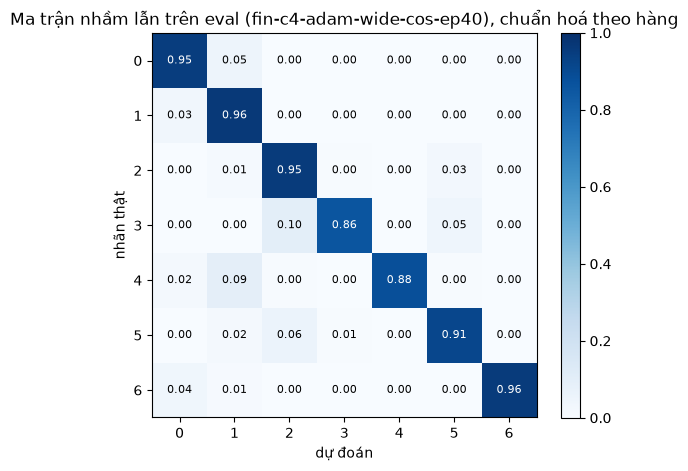

3 kiểu nhầm lớn nhất (tỉ lệ mẫu thật lớp i bị đoán là lớp j): [('3->2', np.float64(0.098)), ('4->1', np.float64(0.095)), ('5->2', np.float64(0.059))]
lớp có F1 thấp nhất: 3 Cottonwood/Willow 0.876


In [20]:
# phân tích lỗi theo lớp (từ eval_result.json của cấu hình cuối cùng)
names = ["0 Spruce/Fir", "1 Lodgepole Pine", "2 Ponderosa Pine", "3 Cottonwood/Willow", "4 Aspen", "5 Douglas-fir", "6 Krummholz"]
pc = pd.DataFrame(EV_FIN["per_class"]).set_index("cls")
pc.index = names
display(pc.round(4))
cm = np.array(EV_FIN["confusion_matrix"])
cmn = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if cmn[i, j] > .5 else "black")
ax.set_xticks(range(7)); ax.set_yticks(range(7)); ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật")
ax.set_title(f"Ma trận nhầm lẫn trên eval ({FINAL_ID}), chuẩn hoá theo hàng"); fig.colorbar(im)
fig.savefig(f"{OUT_DIR}/figures/error_analysis_confusion.png", dpi=110, bbox_inches="tight"); plt.show()
off = [(cmn[i, j], i, j) for i in range(7) for j in range(7) if i != j]
print("3 kiểu nhầm lớn nhất (tỉ lệ mẫu thật lớp i bị đoán là lớp j):", [(f'{i}->{j}', round(v, 3)) for v, i, j in sorted(off, reverse=True)[:3]])
print("lớp có F1 thấp nhất:", pc["f1"].idxmin(), round(pc["f1"].min(), 4))

**Phân tích lỗi:** lớp khó nhất là lớp 3 Cottonwood/Willow (F1 0.876, 549 mẫu ≈ 0.47%), bị nhầm chủ yếu sang lớp 2 Ponderosa Pine (9.8%) và lớp 5 (4.6%). Lớp 4 Aspen (F1 0.894) bị kéo về lớp đa số 1 (9.5%). Nguyên nhân: rất ít mẫu nên đóng góp nhỏ vào loss, cộng với lớp 1 áp đảo (48.8%); cặp 3↔2 có thể có địa hình tương tự (nhận định, chưa kiểm chứng). So với baseline (lớp 4 F1 0.760, 26% bị đoán thành lớp 1) cấu hình cuối cải thiện mạnh nhất ở lớp hiếm. Hướng tiếp: trọng số lớp hoặc oversampling lớp 3/4.

In [21]:
# bảng experiments.xlsx (bằng code, từ results/*.json), eval_* chỉ cho baseline (base-s1) và cấu hình cuối cùng
saved = {r["cfg"]["exp_id"]: r for r in load_results(f"{OUT_DIR}/results")}
rows = []
for i in EXP_ORDER:
    ev = EV_BASE if i == "base-s1" else (EV_FIN if i == FINAL_ID else None)
    rows.append(to_row(saved[i], ev))
SUMMARY_NOTES = {"baseline": "3 seed: val macro-F1 0.8607 ± 0.0030 (2σ = 0.006).", "loss": "MSE kém CE rõ rệt ở mọi lr thử (0.60–0.77 vs 0.86).", "optimizer": "Adam(3e-3) 0.868 ≳ AdamW 0.865 ≈ SGD+mom(0.3) 0.861 > SGD(1.0) 0.834; Adam–SGDm sát ngưỡng 2σ; AdamW(wd=0) ≡ Adam.", "hparam": "M-wide và 40 epoch tốt hơn (vượt 2σ); M-deep, batch 2048, wd 1e-4 tệ hơn; batch 128 cần lr/4.", "dropout": "Mọi q đều tệ hơn (underfitting); baseline chưa quá khớp.", "clipping": "lr 0.3: không giúp; lr 1.0: cứu một phần (0.773 → 0.81/0.83); lr 3.0: không cứu được.", "amp": "Chất lượng ≈ FP32 (trong ~2σ); M-base không nhanh hơn, mạng 2048-2048 FP16 nhanh ≈ 2×. Thời gian chỉ so sánh tương đối (GPU không dành riêng).", "init": "zeros hỏng (đoán lớp đa số); normal/xavier/default/he tương đương ở mạng 3 lớp.", "final": "Adam + M-wide + cosine + 40 epoch: val 0.9264 ± 0.0010 (3 seed), eval 0.9294."}
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           baseline_ids=["base-s1", "base-s2", "base-s3"], summary_notes=SUMMARY_NOTES)
import openpyxl
wb = openpyxl.load_workbook(f"{OUT_DIR}/experiments.xlsx")
n_rows = sum(1 for r in wb["Experiments"].iter_rows(min_row=2, max_col=1) if r[0].value)
figs = [f for f in os.listdir(f"{OUT_DIR}/figures") if f.endswith(".png") and not f.startswith(("compare_", "error_"))]
print("sheet:", wb.sheetnames, "| số dòng thí nghiệm:", n_rows, "| số ảnh figures/<exp_id>.png:", len(figs))
assert n_rows == len(figs) == len(EXP_ORDER) and all(f"{i}.png" in figs for i in EXP_ORDER)
assert len(set(EXP_ORDER)) == len(EXP_ORDER)

sheet: ['Legend', 'Experiments', 'Seeds', 'Summary'] | số dòng thí nghiệm: 57 | số ảnh figures/<exp_id>.png: 57


Kiểm tra cuối: không còn `NotImplementedError` trong `code/`, `predictions_eval.csv` qua `scripts/evaluate.py`, `eval_result.json` là đầu ra nguyên bản của script, số trong `experiments.xlsx`/`REPORT.md` khớp `results/*.json`.
Mở `experiments.xlsx` bằng Excel/LibreOffice để các công thức tự tính lại.

In [22]:
import glob
bad = [f for f in glob.glob("*.py") if "NotImplementedError" in open(f, encoding="utf-8").read()]
print("file còn NotImplementedError:", bad)
assert not bad

file còn NotImplementedError: []
